# Алгоритмы кластеризации
- KMeans  
Разбивает данные на k кластеров, размещая центры (центроиды) и
распределяя объекты по ближайшему центру.

- DBSCAN  (Density-Based Spatial Clustering of Applications with Noise)
Объединяет точки в кластеры на основе плотности.
Позволяет находить кластеры произвольной формы и выделять шум (выбросы).

- Иерархическую кластеризацию  
Строит дерево (иерархию) кластеров, последовательно объединяя
ближайшие объекты в группы.

Примеры применения:
- сегментация клиентов
- анализ пользователей
- поиск структуры в данных

Важно:
Кластеризация — это обучение без учителя.
Правильного ответа здесь не существует.

## 1. Импорт библиотек и данные

В этом занятии мы используем синтетический датасет, сгенерированный с помощью функции make_blobs из sklearn.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# импортируем датасет
from sklearn.datasets import make_blobs

# импорт для масштабирования данных
from sklearn.preprocessing import StandardScaler

# sklearn — основная библиотека для машинного обучения в Python
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.cluster.hierarchy import dendrogram, linkage

## 2. Создание и описание датасета

Описание датасета:

Используем синтетические данные (make_blobs):
- 500 объектов
- 2 признака
- 4 скрытых кластера

Мы НЕ используем истинные метки кластеров,
так как кластеризация — это обучение без учителя.

In [ ]:
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.5, random_state=42)

# преобразуем в датафрейм для удобства
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])

df.head()

,feature_1,feature_2
0,-7.114418,6.268758
1,-10.924957,-6.961552
2,7.924583,0.760722
3,-3.097360,6.819014
4,-5.077806,-7.492223


In [ ]:
# рассмотрим диапазоны значений (полезно перед масштабированием)

print(df.describe())

        feature_1   feature_2
count  500.000000  500.000000
mean    -3.387676    2.908873
std      5.390165    6.454888
min    -11.214182  -10.196813
25%     -7.864795   -1.842668
50%     -4.811723    4.663269
75%      0.770736    8.301364
max      9.258200   14.793383


## 3. Визуализация

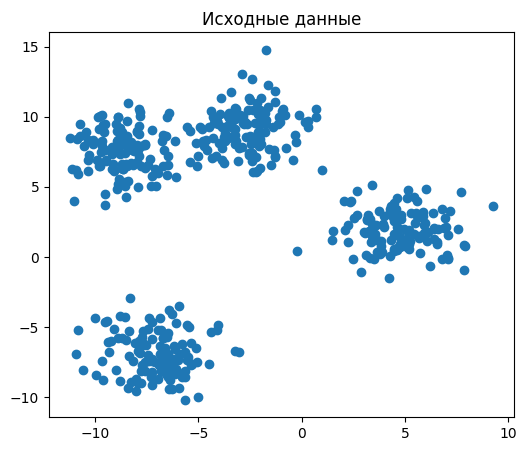

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(df['feature_1'], df['feature_2'])
plt.title("Исходные данные")
plt.show()

На этом этапе у нас нет информации о кластерах — мы просто смотрим на структуру данных.

На графике видно, что данные разбиваются примерно на несколько отдельных групп (кластеров).  
Внутри групп расположены близко друг к другу, а между группами есть заметные расстояния.  
Можно заметить отдельные точки, которые находятся дальше остальных — это могут быть выбросы.  

## 4. Масштабирование признаков

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
print("Пример после масштабирования:", X_scaled[:5])

Пример после масштабирования: [[-0.69208903  0.52103923]
 [-1.39973998 -1.53067109]
 [ 2.10078679 -0.33312777]
 [ 0.05391424  0.60637092]
 [-0.31387223 -1.61296565]]


Кластеризация чувствительна к масштабу признаков, поэтому обязательно нормализуем данные.

## 5. KMeans кластеризация

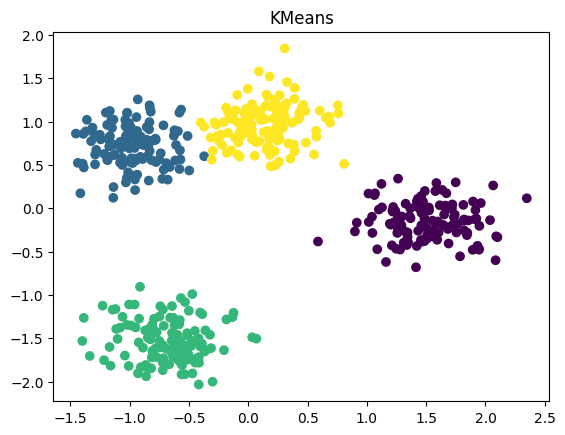

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap='viridis')
plt.title("KMeans")
plt.show()

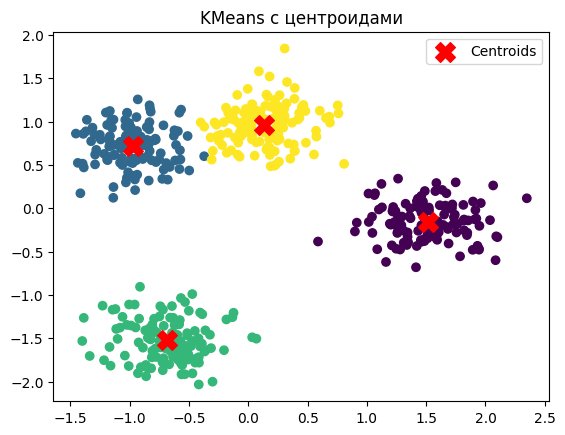

In [ ]:
# визуализируем центроиды кластеров

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

centroids = kmeans.cluster_centers_

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, marker='X', label='Centroids')

plt.title("KMeans с центроидами")
plt.legend()
plt.show()

Алгоритм работает так: сначала случайно выбираются центры кластеров, затем каждый объект относится к ближайшему центру, после чего центры пересчитываются как среднее значение объектов в кластере. Этот процесс повторяется несколько раз, пока кластеры не стабилизируются. В итоге мы получаем группы похожих объектов и их центры (центроиды), которые помогают понять, чем кластеры отличаются друг от друга.

Алгоритм разбивает данные на кластеры вокруг центров и минимизирует расстояние до них.

Алгоритм KMeans успешно разделил данные на 4 чёткие группы, которые хорошо отделены друг от друга.  
Точки внутри каждого кластера находятся близко, значит разбиение получилось качественным.  

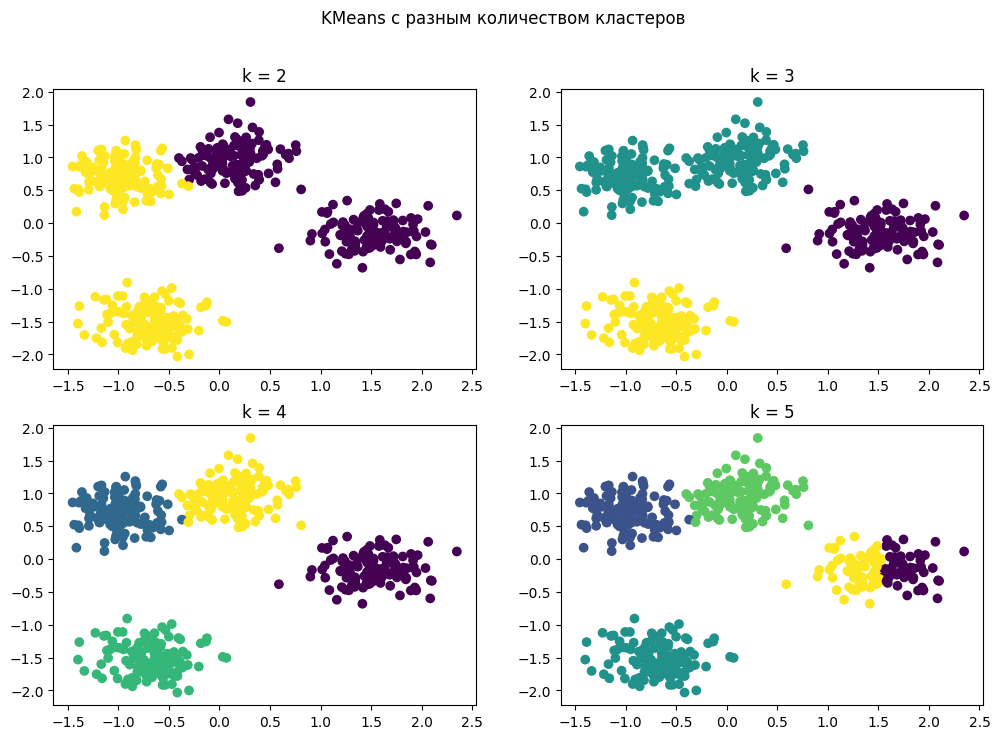

In [ ]:
# Попробуем разные значения k
k_values = [2, 3, 4, 5]

plt.figure(figsize=(12, 8))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    plt.subplot(2, 2, i+1)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
    plt.title(f"k = {k}")

plt.suptitle("KMeans с разным количеством кластеров")
plt.show()

Здесь мы применяем KMeans с разным количеством кластеров (k),
чтобы увидеть, как меняется разбиение данных.  

Можно заметить:  
- при k = 2 алгоритм объединяет несколько естественных групп в один кластер  
- при k = 3 разделение становится лучше, но всё ещё не идеально  
- при k = 4 кластеры совпадают с реальной структурой данных  
- при k = 5 алгоритм начинает «дробить» кластеры на более мелкие части  

Это показывает, что важно правильно выбирать количество кластеров.  
Слишком маленькое k объединяет разные группы,  
а слишком большое — разбивает их без необходимости.  

## 6. Подбор числа кластеров (Elbow Method)

Ищем точку перегиба — после неё улучшение качества замедляется.


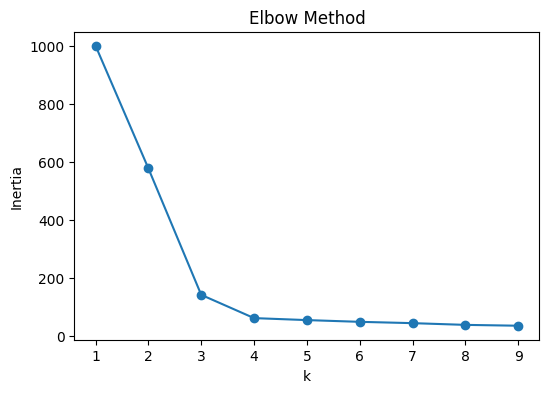

In [ ]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print('Ищем точку перегиба — после неё улучшение качества замедляется.')

plt.figure(figsize=(6, 4))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

На графике видно, что после k≈4 снижение inertia становится значительно менее заметным — появляется «локоть».  
Это значит, что оптимальное количество кластеров — около 4, так как дальнейшее увеличение почти не улучшает качество.  

Inertia — это мера того, насколько близко точки находятся к центру своего кластера.  
Проще говоря: это сумма расстояний (в квадрате) от каждой точки до центра своего кластера.

## 7. Silhouette Score

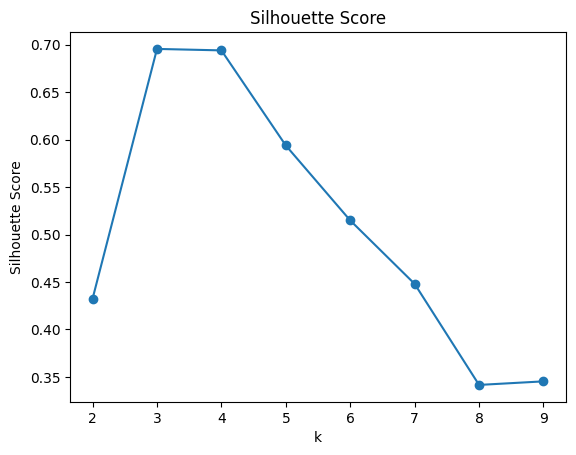

In [ ]:
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

Силуэт показывает, насколько хорошо объекты ищутся внутри своих кластеров.  


На графике видно, что максимальное значение silhouette score достигается при
k=3 или k=4.  
Это значит, что именно при таком количестве кластеров данные разделяются лучше всего.  
При увеличении числа кластеров качество начинает ухудшаться, кластеры становятся менее чёткими.  

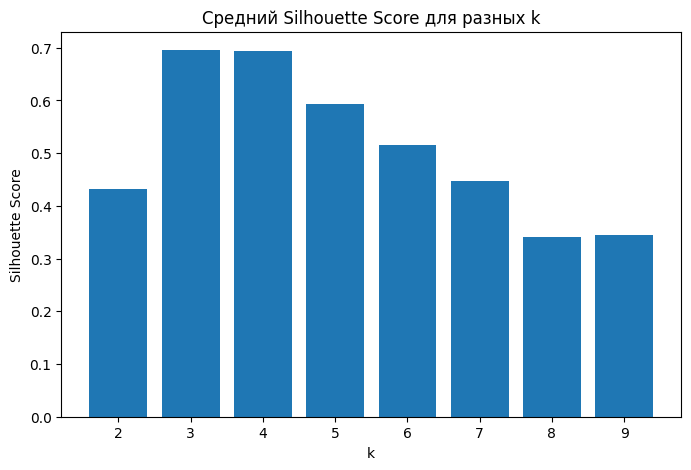

In [ ]:
k_values = list(range(2, 10))

plt.figure(figsize=(8, 5))
plt.bar(k_values, silhouette_scores)

plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Средний Silhouette Score для разных k")

plt.show()

Здесь мы строим столбчатую диаграмму среднего silhouette score
для разных значений k.  

Это позволяет наглядно сравнить качество кластеризации
при разном количестве кластеров.  

Чем выше значение — тем лучше объекты распределены по кластерам.  

Теперь посмотрим, как меняются метрики качества при разном количестве кластеров.

Davies-Bouldin показывает, насколько кластеры похожи друг на друга (чем они дальше и чётче разделены, тем значение меньше и лучше)    
Calinski-Harabasz (Калински-Харабаш) оценивает, насколько объекты внутри кластеров близки друг к другу и одновременно далеко от других кластеров (чем больше, тем лучше).

Это помогает понять, при каком k кластеризация наиболее качественная.  

Обычно оптимальное значение k:  
- соответствует минимуму Davies-Bouldin  
- и максимуму Calinski-Harabasz  

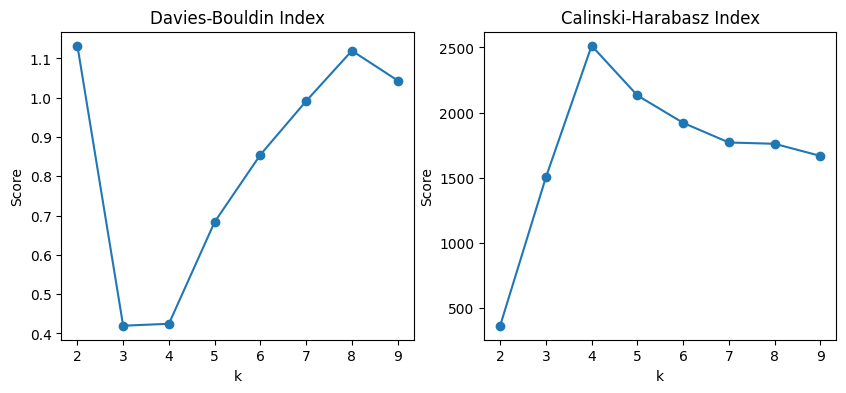

In [ ]:
k_values = range(2, 10)

db_scores = []
ch_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, db_scores, marker='o')
plt.title("Davies-Bouldin Index")
plt.xlabel("k")
plt.ylabel("Score")

plt.subplot(1, 2, 2)
plt.plot(k_values, ch_scores, marker='o')
plt.title("Calinski-Harabasz Index")
plt.xlabel("k")
plt.ylabel("Score")

plt.show()

По графикам видно, что лучшее качество достигается при k≈3–4: здесь Davies-Bouldin минимален, а Calinski-Harabasz максимален.  
Это значит, что при таком количестве кластеров данные разделяются наиболее чётко, а дальнейшее увеличение k уже не даёт улучшения.  

## 8. DBSCAN

DBSCAN ищет области высокой плотности и может выделять выбросы.

DBSCAN — Density-Based Spatial Clustering of Applications with Noise
(кластеризация на основе плотности с учётом шума)  

DBSCAN объединяет точки в кластеры, если они находятся близко друг к другу и образуют плотные области. Если точка находится далеко от других и вокруг неё мало соседей, она считается шумом (выбросом).   
Такой алгоритм хорошо находит кластеры сложной формы и не требует заранее задавать их количество.  

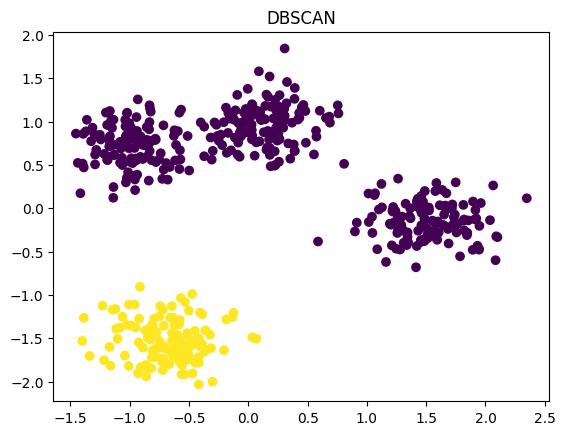

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan)
plt.title("DBSCAN")
plt.show()

In [ ]:
print("Количество кластеров:", len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0))
print("Количество шумовых точек:", list(labels_dbscan).count(-1))

Количество кластеров: 2
Количество шумовых точек: 0


Параметр eps задаёт радиус вокруг точки — насколько близко должны находиться другие точки, чтобы считаться соседями. Параметр min_samples определяет минимальное количество точек внутри этого радиуса, чтобы точка считалась частью кластера (ядром). Если вокруг точки мало соседей, она считается шумом, поэтому эти параметры помогают определить, где есть плотные группы, а где — выбросы.

DBSCAN выделил кластеры на основе плотности точек, но объединил несколько групп в один большой кластер.    
Это может означать, что выбранное значение eps слишком большое, и алгоритм считает близкие группы одной областью.  
При этом отдельный кластер снизу хорошо выделился, так как он достаточно плотный и удалённый.  
Можно заметить, что алгоритм не разделил все кластеры так чётко, как KMeans, из-за своих особенностей работы.  

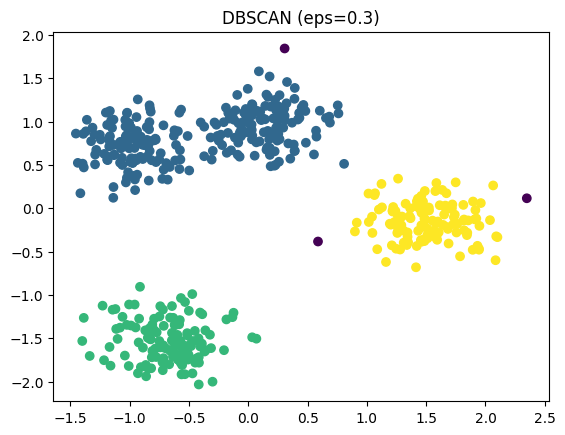

In [ ]:
# Попробуем другие параметры DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan_new = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan_new)
plt.title("DBSCAN (eps=0.3)")
plt.show()

Мы уменьшили параметр eps (радиус соседства).  

Теперь алгоритм стал "строже":  
- точки считаются соседями только если они ближе друг к другу  
- в результате кластеры могут разделяться лучше  
- может появиться больше шума (выбросов)  

После уменьшения параметра eps алгоритм стал лучше разделять кластеры — теперь видно больше отдельных групп.  
При этом появились точки, которые не попали ни в один кластер — это выбросы (шум).  
Это показывает, что подбор параметров сильно влияет на результат DBSCAN.  

In [ ]:
eps_values = [0.2, 0.3, 0.5, 0.7]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    if len(set(labels)) > 1:
        print(f"eps={eps}")
        print("DB:", davies_bouldin_score(X_scaled, labels))
        print("CH:", calinski_harabasz_score(X_scaled, labels))

eps=0.2
DB: 1.4805648767620954
CH: 789.3022472010656
eps=0.3
DB: 1.4567326307955397
CH: 979.0738248368535
eps=0.5
DB: 0.6273546489651581
CH: 432.0275251776799
eps=0.7
DB: 0.6273546489651581
CH: 432.0275251776799


При увеличении параметра eps метрики заметно меняются, что показывает сильную зависимость качества DBSCAN от настроек.  
При eps≈0.5–0.7 значение Davies-Bouldin становится ниже, что говорит о более компактных кластерах, но при этом Calinski-Harabasz уменьшается — кластеры становятся менее разделёнными.  
Это значит, что для DBSCAN важно подбирать параметры, так как от них напрямую зависит результат кластеризации.  

## 9. Иерархическая кластеризация

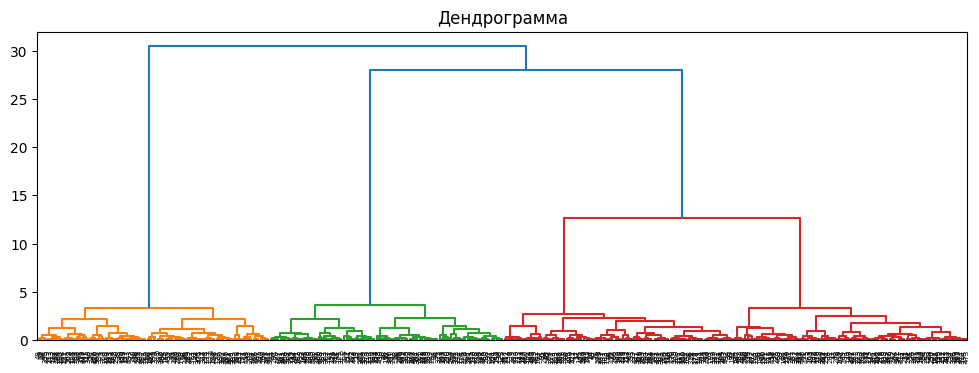

In [ ]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 4))
dendrogram(linked)
plt.title("Дендрограмма")
plt.show()

Иерархическая кластеризация строит дерево объединения объектов.

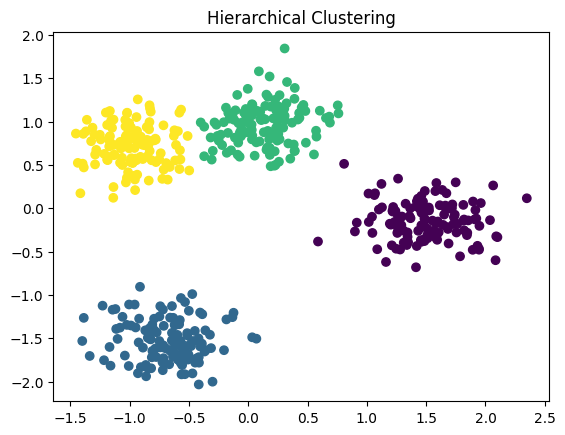

In [ ]:
agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg)
plt.title("Hierarchical Clustering")
plt.show()

Здесь мы применяем иерархическую кластеризацию,
но уже задаём фиксированное количество кластеров (n_clusters=4).  

Алгоритм объединяет ближайшие точки в группы,
пока не получится заданное число кластеров.  

В отличие от дендрограммы, где мы анализируем структуру,
здесь мы сразу получаем готовое разбиение данных.  

То есть дендрограмма — это инструмент анализа, а AgglomerativeClustering — инструмент для получения результата.

## 10. Сравнение метрик

In [ ]:
def evaluate(X, labels):
    return {
        "Silhouette": silhouette_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels)
    }

results = pd.DataFrame({
    "KMeans": evaluate(X_scaled, labels_kmeans),
    "DBSCAN": evaluate(X_scaled, labels_dbscan),
    "Hierarchical": evaluate(X_scaled, labels_agg)
})

results

,KMeans,DBSCAN,Hierarchical
Silhouette,0.694097,0.531507,0.693721
Davies-Bouldin,0.424631,0.627355,0.423666
Calinski-Harabasz,2513.601013,432.027525,2501.505364


Мы используем несколько метрик, потому что каждая отражает качество по-разному.

Silhouette Score (чем больше, тем лучше)  
Показывает, насколько объекты похожи на свой кластер и отличаются от других.
Значения ближе к 1 — хорошее разделение кластеров.  

Davies-Bouldin Index (чем меньше, тем лучше)  
Оценивает, насколько кластеры компактны и хорошо отделены друг от друга.  

Calinski-Harabasz Index (чем больше, тем лучше)  
Показывает соотношение расстояний между кластерами и внутри кластеров.


Выводы:

- KMeans и Hierarchical показывают лучшие результаты по всем метрикам  
- DBSCAN уступает, так как хуже разделил кластеры (объединил некоторые группы).
- KMeans и Hierarchical дают очень похожее качество на этом датасете  

Важно:  
Метрики помогают сравнить алгоритмы, но окончательный выбор
нужно делать с учётом визуализации и интерпретации кластеров.  

Важно: DBSCAN может выделять шум, это влияет на метрики


В кластеризации нет единственно правильного ответа — мы всегда ищем наиболее разумное разбиение данных.

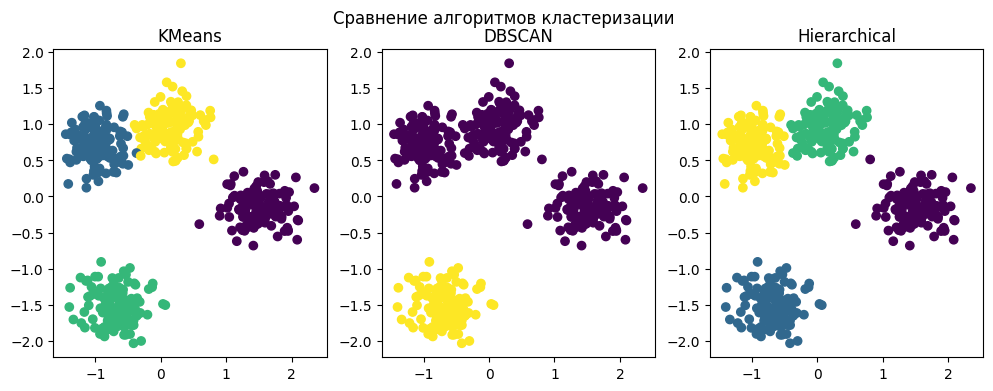

In [ ]:
plt.figure(figsize=(12, 4))

# KMeans
plt.subplot(1, 3, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap='viridis')
plt.title("KMeans")

# DBSCAN
plt.subplot(1, 3, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap='viridis')
plt.title("DBSCAN")

# Hierarchical
plt.subplot(1, 3, 3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg, cmap='viridis')
plt.title("Hierarchical")

plt.suptitle("Сравнение алгоритмов кластеризации")
plt.show()

Теперь сравним алгоритмы визуально.  

Мы отображаем разбиение данных, полученное разными алгоритмами,
в одном пространстве признаков.  

Можно заметить:  
- KMeans формирует компактные и чёткие кластеры  
- DBSCAN объединяет плотные области и может выделять шум  
- Иерархическая кластеризация даёт результат, похожий на KMeans,
  но формируется другим способом  

Это позволяет увидеть, что разные алгоритмы по-разному  
воспринимают структуру данных.  

## 11. Интерпретация кластеров

In [ ]:
df['cluster'] = labels_kmeans

cluster_summary = df.groupby('cluster').mean()
cluster_summary

,feature_1,feature_2
cluster,,
0,4.762797,1.899199
1,-8.643431,7.554174
2,-7.061634,-6.916632
3,-2.656332,9.086494


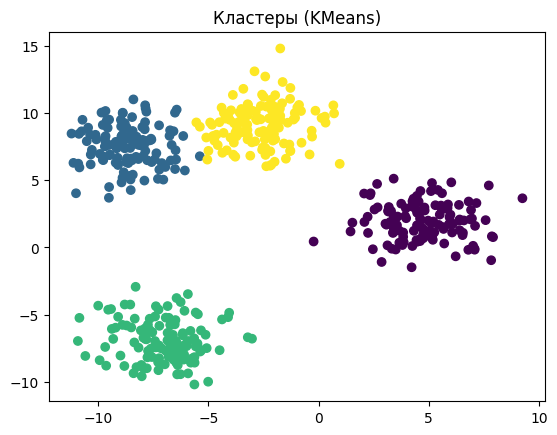

In [ ]:
plt.scatter(df['feature_1'], df['feature_2'], c=df['cluster'], cmap='viridis')
plt.title("Кластеры (KMeans)")
plt.show()

Теперь смотрим, чем отличаются кластеры — это ключ к интерпретации.

Мы посчитали средние значения признаков для каждого кластера, чтобы понять, чем они отличаются друг от друга. Это помогает «описать» кластеры и увидеть, какие группы объектов выделил алгоритм.  

Теперь попробуем интерпретировать кластеры так, как это делается в реальных задачах.  

Мы уже посчитали средние значения признаков для каждого кластера.  
На основе этих значений можно "описать" группы.  

Представим, что это не абстрактные признаки, а например:  
feature_1 — доход клиента  
feature_2 — уровень активности  

Тогда можно интерпретировать кластеры так:  

Кластер 0 — клиенты с высоким доходом и средней активностью    
Кластер 1 — клиенты с низким доходом, но высокой активностью    
Кластер 2 — клиенты с низким доходом и низкой активностью    
Кластер 3 — клиенты со средней доходностью, но высокой активностью    

Такая интерпретация помогает бизнесу принимать решения:  
например, кому предлагать премиальные услуги,  
а кого — стимулировать к активности.  

## 12. Влияние масштабирования

Теперь специально создадим ситуацию, где признаки имеют разный масштаб.  

Мы увеличили один признак в 100 раз.

In [ ]:
# искусственно меняем масштаб одного признака
df_bad = df.copy()
df_bad['feature_1'] = df_bad['feature_1'] * 100

X_bad = df_bad.values

In [ ]:
# KMeans БЕЗ масштабирования

kmeans_bad = KMeans(n_clusters=4, random_state=42)
labels_bad = kmeans_bad.fit_predict(X_bad)

In [ ]:
# KMeans С масштабированием

scaler = StandardScaler()
X_bad_scaled = scaler.fit_transform(X_bad)

kmeans_scaled = KMeans(n_clusters=4, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_bad_scaled)

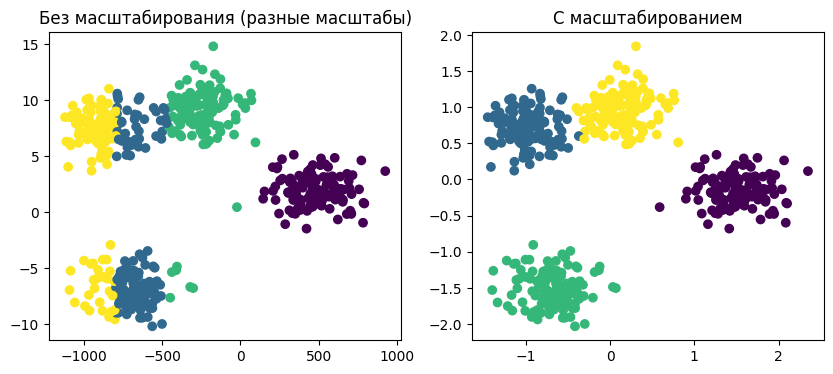

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_bad[:,0], X_bad[:,1], c=labels_bad)
plt.title("Без масштабирования (разные масштабы)")

plt.subplot(1,2,2)
plt.scatter(X_bad_scaled[:,0], X_bad_scaled[:,1], c=labels_scaled)
plt.title("С масштабированием")

plt.show()

Без масштабирования KMeans начинает ориентироваться в основном на этот признак и игнорирует второй.

После масштабирования признаки становятся сопоставимыми, и кластеры снова определяются корректно.

Это показывает, почему нормализация — важный шаг в задачах кластеризации.

Без нормализации результат может сильно отличаться.

В этом примере видно, что без масштабирования результат кластеризации может отличаться, потому что признаки имеют разный диапазон значений. Алгоритм KMeans ориентируется на расстояния между точками, и если один признак имеет большие значения, он начинает сильнее влиять на результат. В итоге модель может «смотреть» больше на один признак и хуже учитывать другие. Поэтому масштабирование помогает уравнять вклад всех признаков и получить более корректное и сбалансированное разбиение на кластеры.